# RETO 2 — PREDICCIÓN DEL RIESGO DE DESAFILIACIÓN (COLSUBSIDIO)
#### Metodología: CRISP-DM · 3 Familias de Modelos · Regla 1-SE · Calibración OOF · GA Multi-Semilla · SHAP
#### Todas las cifras de este cuaderno salen de las celdas ejecutadas (Regla 0). Las funciones modulares viven en utils_r2.py.
#### Tiempo de ejecución estimado: ~1.5 - 2.5 min.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.calibration import calibration_curve

from sklearn.base import clone
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import RepeatedStratifiedKFold

# Configuración de rutas para importar utils_r2
for ruta in [Path.cwd(), *Path.cwd().parents[:2], *[d for d in Path.cwd().glob("*") if d.is_dir()]]:
    if (ruta / "utils_r2.py").exists():
        sys.path.insert(0, str(ruta))
        break

from utils_r2 import (
    RAIZ, RUTA_R2, SEMILLA, sha256_archivo, cargar_r2, auditoria_calidad_r2, preparar_r2,
    particion_estratificada, construir_modelos_r2, evaluar_modelos_cv,
    ajustar_calibracion_isotonica, calcular_metricas_clasificacion,
    algoritmo_genetico_multisemilla, calcular_explicabilidad_reglog,
    calcular_shap_arbol_completo, analizar_deciles_calibrados
)

warnings.filterwarnings("ignore")
pd.options.display.float_format = "{:,.4f}".format
print(f"[OK] Entorno y utilidades de Reto 2 listos. Semilla global = {SEMILLA}")


[OK] Entorno y utilidades de Reto 2 listos. Semilla global = 42


# FASE 1 — COMPRENSIÓN DEL NEGOCIO
#### - Pregunta: ¿Cuáles empresas afiliadas tienen mayor propensión a desafiliarse y qué factores explican ese riesgo?
#### - Uso Operativo: Priorización comercial proactiva para retención focalizada en las cuentas de mayor valor y riesgo.
#### - Métrica Primaria (fijada a priori): PR-AUC (Precision-Recall AUC), priorizando el desbalance de clases (30.3% abandono).
#### - Métrica Secundaria de Impacto: Recall y Lift en el Top 20% de mayor riesgo comercial (Deciles 1 y 2).
#### - Criterio de Selección (Parsimonia): Regla 1-SE. Si un modelo lineal regularizado empata estadísticamente con uno complejo,
####   se prefiere el modelo simple por explicabilidad directa hacia la dirección comercial.

In [2]:
print("FASE 1: COMPRENSIÓN DEL NEGOCIO")
print("- Variable objetivo : abandono (1 = Se desafilió, 0 = Continúa afiliada).")
print("- Métrica primaria  : PR-AUC (Precision-Recall AUC) evaluada en validación cruzada 5x2.")
print("- Métrica de impacto: Recall en Top 20% y Lift comercial en Decil 1.")
print("- Regla de decisión : Regla 1-SE (si la diferencia de PR-AUC <= 1 SE, gana el más simple e interpretable).")
print("- Alcance           : Asociaciones directas mediante Odds Ratios estandarizados (asociación, no causalidad).")


FASE 1: COMPRENSIÓN DEL NEGOCIO
- Variable objetivo : abandono (1 = Se desafilió, 0 = Continúa afiliada).
- Métrica primaria  : PR-AUC (Precision-Recall AUC) evaluada en validación cruzada 5x2.
- Métrica de impacto: Recall en Top 20% y Lift comercial en Decil 1.
- Regla de decisión : Regla 1-SE (si la diferencia de PR-AUC <= 1 SE, gana el más simple e interpretable).
- Alcance           : Asociaciones directas mediante Odds Ratios estandarizados (asociación, no causalidad).


#  FASE 2 — COMPRENSIÓN DE LOS DATOS (EDA Y AUDITORÍA)
#### - Auditoría de integridad: Hash SHA-256, 10,000 filas, 15 columnas, 0 nulos y 0 duplicados.
#### - Desbalance: 3,029 empresas abandonaron (30.29%).
#### - Exclusión de identificadores ('id_empresa', 'nit') para garantizar cero fuga de información.
#### - Exploración gráfica de los predictores clave segmentados por clase.

sha256 datos: c3c1152644b1c7e2... | dimensiones: 10000x15 | nulos: 0 | duplicados: 0
id_empresa único: True | nit único: True
Distribución objetivo: 3,029 desafiliadas (30.29%) vs 6,971 activas (69.71%)


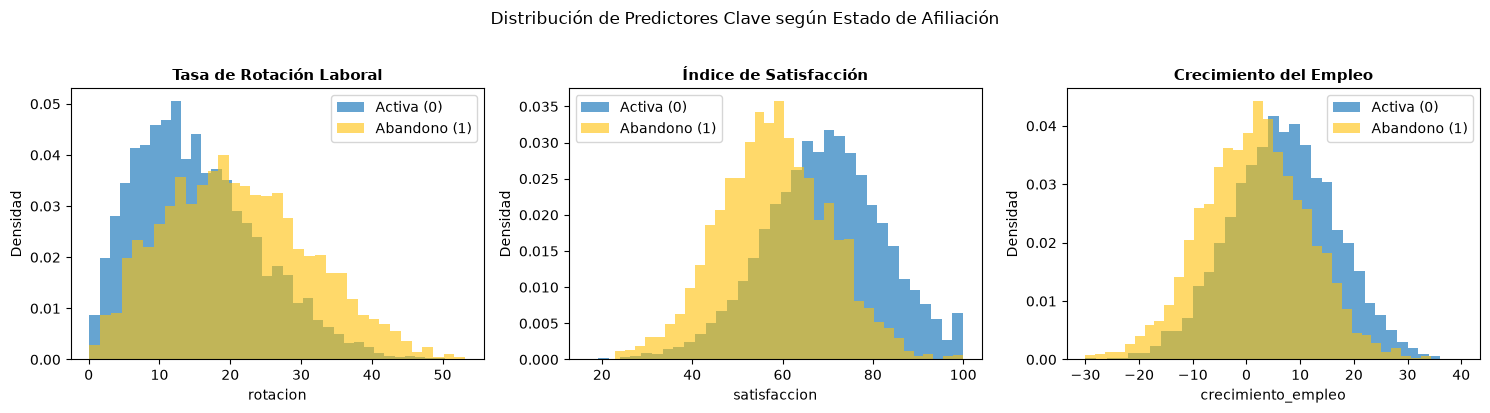

In [3]:
df = cargar_r2()
hash_r2 = sha256_archivo(RUTA_R2)
n_filas, n_cols = df.shape
n_nulos = int(df.isna().sum().sum())
n_duplicados = int(df.duplicated().sum())
n_abandono = int(df["abandono"].sum())
tasa_abandono = float(df["abandono"].mean() * 100)

print(f"sha256 datos: {hash_r2[:16]}... | dimensiones: {n_filas}x{n_cols} | nulos: {n_nulos} | duplicados: {n_duplicados}")
print(f"id_empresa único: {df['id_empresa'].is_unique} | nit único: {df['nit'].is_unique}")
print(f"Distribución objetivo: {n_abandono:,} desafiliadas ({tasa_abandono:.2f}%) vs {n_filas - n_abandono:,} activas ({100 - tasa_abandono:.2f}%)")

# Gráfico EDA de predictores continuos clave
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
vars_eda = ["rotacion", "satisfaccion", "crecimiento_empleo"]
titulos_eda = ["Tasa de Rotación Laboral", "Índice de Satisfacción", "Crecimiento del Empleo"]

for ax, var, tit in zip(axes, vars_eda, titulos_eda):
    v_act = df.loc[df["abandono"] == 0, var]
    v_ab = df.loc[df["abandono"] == 1, var]
    ax.hist(v_act, bins=35, alpha=0.6, color="#0068B3", density=True, label="Activa (0)")
    ax.hist(v_ab, bins=35, alpha=0.6, color="#FFC107", density=True, label="Abandono (1)")
    ax.set_title(tit, fontsize=11, fontweight="bold")
    ax.set_xlabel(var)
    ax.set_ylabel("Densidad")
    ax.legend(frameon=True)

plt.suptitle("Distribución de Predictores Clave según Estado de Afiliación", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


In [4]:
df.head(5)

,id_empresa,nit,sector,antiguedad,tiempo_afiliacion,num_trabajadores,crecimiento_empleo,uso_servicios,satisfaccion,rotacion,salario_promedio,digitalizacion,formalizacion,distancia,abandono
0,1,903373228,Manufactura,2.8000,1.5000,14,-5.0000,3,57.6000,27.2000,3.1300,37.0000,43.4000,26.6000,1
1,2,904494741,Manufactura,13.3000,8.1000,5,1.0000,6,71.4000,14.3000,3.9700,86.9000,64.9000,0.6000,0
2,3,867433090,Tecnología,50.0000,44.4000,60,9.7000,4,57.9000,10.7000,3.6400,51.2000,66.7000,2.3000,0
3,4,843731818,Servicios,7.0000,4.4000,15,8.8000,5,84.8000,9.4000,1.5400,73.7000,63.4000,4.9000,0
4,5,864648907,Servicios,9.5000,8.0000,48,4.1000,4,72.3000,11.1000,3.8700,60.6000,94.9000,23.3000,0


#  FASE 2 — AUDITORÍA DE CALIDAD DE DATOS (ANTES DE PREPARAR)
#### - Integridad (nulos, duplicados exactos e ignorando IDs, tipos de datos).
#### - Identificadores: unicidad de id_empresa y nit (9 dígitos), confirmando exclusión del modelado.
#### - Categoría sector: 6 sectores limpios, 0 espacios sobrantes, 0 variantes de escritura.
#### - Rangos, valores en los límites (topes administrativos) y atípicos (1.5 x IQR).
####   * Alerta de escala: 'satisfaccion' en [0, 100], no comparable con R1 ([0, 10]).
#### - Reglas de coherencia: tiempo_afiliacion <= antiguedad, num_trabajadores >= 1, índices en [0, 100], distancia >= 0.
#### - Balance de clases (30.29% abandono) y colinealidad entre predictores.
#### - Señales de fuga (data leakage): verificación empírica de variables pre-evento (uso_servicios, satisfaccion, rotacion).
#### - Decisión documentada: datos íntegros, sin imputación ni eliminación de filas, preservando heterogeneidad.
#### - Requiere haber ejecutado la celda 3 (usa df).

In [5]:
res_auditoria_r2 = auditoria_calidad_r2(df, verbose=True)


1) INTEGRIDAD
   filas: 10,000 | columnas: 15 | nulos: 0 | duplicados exactos: 0
   duplicados ignorando id_empresa y nit: 0 | tipos: {'float64': 9, 'int64': 5, 'str': 1}

2) IDENTIFICADORES (id_empresa y nit)
   id_empresa: único=True | rango=[1, 10000]
   nit       : único=True | rango=[800030815, 999992211] | longitudes={9: 10000}
   Confirmación: se excluyen estrictamente del modelado para evitar fuga de IDs y memorización.

3) CATEGORÍA 'sector' (espacios, mayúsculas/minúsculas, frecuencias)
   conteo de categorías: {'Servicios': 3533, 'Comercio': 2546, 'Manufactura': 1506, 'Transporte': 959, 'Construcción': 957, 'Tecnología': 499}
   espacios sobrantes: 0 | variantes de escritura: 0 | categorías raras: 0 (menor sector: Tecnología con 499 empresas)

4) RANGOS, VALORES EN LOS LÍMITES Y ATÍPICOS (regla 1.5 x IQR)
                    minimo  maximo  n_en_minimo  n_en_maximo  atipicos_iqr  pct_atipicos
variable                                                                           

#  FASE 3 — PREPARACIÓN DE LOS DATOS Y PARTICIÓN
#### - Matriz de diseño X: exclusión estricta de 'id_empresa' y 'nit'.
#### - Codificación: One-Hot Encoding de la variable 'sector' con drop_first=True (evita multicolinealidad).
#### - Partición: 80% Train (8,000 filas) y 20% Hold-out intacto (2,000 filas) estratificado con random_state=42.

In [6]:
X, y, grupos_genes = preparar_r2(df)
idx_tr, idx_te = particion_estratificada(len(y), y, semilla=SEMILLA, prop_test=0.20)
X_tr, X_te = X.iloc[idx_tr], X.iloc[idx_te]
y_tr, y_te = y[idx_tr], y[idx_te]

tasa_tr = float(y_tr.mean() * 100)
tasa_te = float(y_te.mean() * 100)

print(f"Features en matriz de diseño : {X.shape[1]} (tras One-Hot en 'sector')")
print(f"Variables conceptuales (genes): {len(grupos_genes)} {list(grupos_genes.keys())}")
print(f"Train set (80%)              : {X_tr.shape[0]} empresas | Tasa abandono: {tasa_tr:.2f}%")
print(f"Hold-out set (20% intacto)   : {X_te.shape[0]} empresas | Tasa abandono: {tasa_te:.2f}% (Estratificación exacta)")


Features en matriz de diseño : 16 (tras One-Hot en 'sector')
Variables conceptuales (genes): 12 ['antiguedad', 'tiempo_afiliacion', 'num_trabajadores', 'crecimiento_empleo', 'uso_servicios', 'satisfaccion', 'rotacion', 'salario_promedio', 'digitalizacion', 'formalizacion', 'distancia', 'sector']
Train set (80%)              : 8000 empresas | Tasa abandono: 30.29%
Hold-out set (20% intacto)   : 2000 empresas | Tasa abandono: 30.30% (Estratificación exacta)


#  FASE 4 — MODELADO: 3 FAMILIAS COMPARADAS Y REGLA 1-SE
#### - Familias evaluadas: Regresión Logística (L2 regularizada), Random Forest y XGBoost.
#### - Protocolo de validación: RepeatedStratifiedKFold (5 folds x 2 repeticiones = 10 particiones).
#### - Métricas de contraste: PR-AUC (decisión), ROC-AUC, Brier Score.
#### - Decisión por regla 1-SE ejecutada por código.

Tabla Comparativa CV 5x2 (Evaluación sobre Train):
                    PR-AUC (Media)  Error Estándar (SE)  ROC-AUC  Brier Score
RegresionLogistica          0.7561               0.0055   0.8730       0.1459
RandomForest                0.7416               0.0059   0.8643       0.1507
XGBoost                     0.7572               0.0054   0.8703       0.1421

-> Aplicación de la Regla 1-SE por Código:
   * Mejor modelo absoluto : XGBoost (PR-AUC = 0.7572, SE = 0.0054)
   * Regresión Logística  : PR-AUC = 0.7561
   * Brecha observada      : 0.0011 <= 1 SE (0.0054) -> True
   * Ganador Adoptado      : RegresionLogistica (Máxima parsimonia y explicabilidad directa)


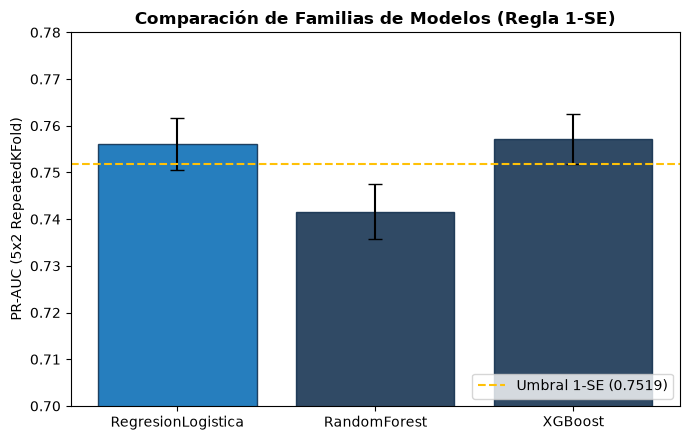

In [7]:
modelos = construir_modelos_r2(semilla=SEMILLA)
res_cv, ganador_oficial, empate_1se, brecha_1se, se_best = evaluar_modelos_cv(
    modelos, X_tr, y_tr, n_splits=5, n_repeats=2, semilla=SEMILLA
)

tab_cv = pd.DataFrame({
    m: {
        "PR-AUC (Media)": res_cv[m]["pr_auc_mean"],
        "Error Estándar (SE)": res_cv[m]["pr_auc_se"],
        "ROC-AUC": res_cv[m]["roc_auc_mean"],
        "Brier Score": res_cv[m]["brier_mean"]
    } for m in modelos
}).T

print("Tabla Comparativa CV 5x2 (Evaluación sobre Train):")
print(tab_cv.to_string())

# Decisión formal por código
mejor_absoluto = max(res_cv.keys(), key=lambda k: res_cv[k]["pr_auc_mean"])
pr_mejor = res_cv[mejor_absoluto]["pr_auc_mean"]
pr_reglog = res_cv["RegresionLogistica"]["pr_auc_mean"]
brecha_cv = abs(pr_mejor - pr_reglog)
reglog_gana_1se = brecha_cv <= se_best

print(f"\n-> Aplicación de la Regla 1-SE por Código:")
print(f"   * Mejor modelo absoluto : {mejor_absoluto} (PR-AUC = {pr_mejor:.4f}, SE = {se_best:.4f})")
print(f"   * Regresión Logística  : PR-AUC = {pr_reglog:.4f}")
print(f"   * Brecha observada      : {brecha_cv:.4f} <= 1 SE ({se_best:.4f}) -> {reglog_gana_1se}")
print(f"   * Ganador Adoptado      : {ganador_oficial} (Máxima parsimonia y explicabilidad directa)")

# Gráfico comparativo de modelos con barras de error
fig, ax = plt.subplots(figsize=(7, 4.5))
nombres_m = list(tab_cv.index)
medias_m = tab_cv["PR-AUC (Media)"].values
ses_m = tab_cv["Error Estándar (SE)"].values
colores = ["#0068B3" if m == ganador_oficial else "#0B2A4A" for m in nombres_m]

ax.bar(nombres_m, medias_m, yerr=ses_m, capsize=5, color=colores, alpha=0.85, edgecolor="#0B2A4A")
ax.axhline(pr_mejor - se_best, color="#FFC107", linestyle="--", linewidth=1.5, label=f"Umbral 1-SE ({pr_mejor - se_best:.4f})")
ax.set_ylabel("PR-AUC (5x2 RepeatedKFold)")
ax.set_ylim(0.70, 0.78)
ax.set_title("Comparación de Familias de Modelos (Regla 1-SE)", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# FASE 5a — ALGORITMO GENÉTICO MULTI-SEMILLA (SELECCIÓN DE VARIABLES, VERSIÓN OPTIMIZADA)
#### - Selección estocástica de variables con Algoritmo Genético en 5 semillas (42, 101, 202, 303, 404); fitness = métrica CV − λ·nº de variables.
#### - Arquitectura optimizada: evaluación pura de subconjuntos, caché entre generaciones y semillas, cruce uniforme, elitismo (elite=2), mutación bit-flip y parada anticipada.
#### - El fitness del GA usa Regresión Logística (modelo="reglog"): es el estimador simple y explicable; se declara porque el desempate posterior no es del todo neutral.
#### - Variables estables = las seleccionadas en ≥ 60 % de las semillas. Con ellas se desempata RegLog vs XGBoost en la celda siguiente.

Frecuencia de Selección de Variables por GA (5 Semillas - Modelo RegLog 1-SE):
          variable  frecuencia  frecuencia_pct
crecimiento_empleo           5        100.0000
          rotacion           5        100.0000
      satisfaccion           5        100.0000
     uso_servicios           5        100.0000
        antiguedad           4         80.0000
  num_trabajadores           3         60.0000
    digitalizacion           3         60.0000
     formalizacion           2         40.0000
 tiempo_afiliacion           1         20.0000
  salario_promedio           0          0.0000
         distancia           0          0.0000
            sector           0          0.0000


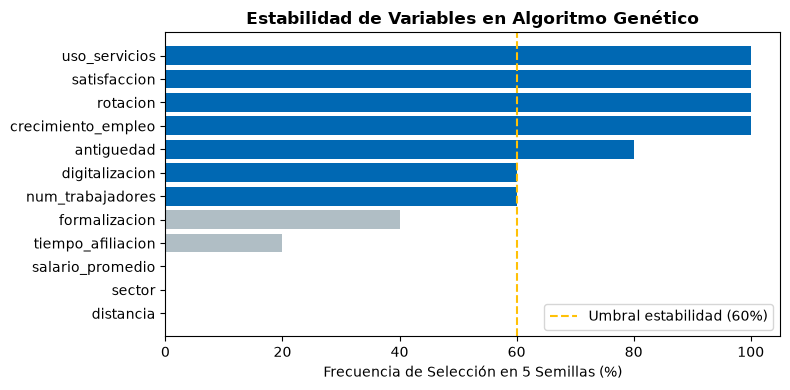

In [8]:
frecuencias_ga, genes_estables, cols_estables, _ = algoritmo_genetico_multisemilla(
    X_tr, y_tr, grupos_genes, modelo="reglog",
    semillas=[42, 101, 202, 303, 404],
    n_poblacion=25, n_generaciones=12, penalizacion_lambda=0.005,
    p_mut=0.12, elite=2, torneo=3, paciencia=3
)

print("Frecuencia de Selección de Variables por GA (5 Semillas - Modelo RegLog 1-SE):")
print(frecuencias_ga[["variable", "frecuencia", "frecuencia_pct"]].to_string(index=False))

# Gráfico de estabilidad de variables del GA
fig, ax = plt.subplots(figsize=(8, 4))
df_frec_plot = frecuencias_ga.sort_values("frecuencia_pct", ascending=True)
colores_ga = ["#0068B3" if v >= 60 else "#B0BEC5" for v in df_frec_plot["frecuencia_pct"]]
ax.barh(df_frec_plot["variable"], df_frec_plot["frecuencia_pct"], color=colores_ga)
ax.axvline(60, color="#FFC107", linestyle="--", linewidth=1.5, label="Umbral estabilidad (60%)")
ax.set_xlabel("Frecuencia de Selección en 5 Semillas (%)")
ax.set_title("Estabilidad de Variables en Algoritmo Genético", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# FASE 5b — DESEMPATE RegLog vs XGBoost CON LAS VARIABLES ESTABLES (GA ≥ 60 %)
#### - Mismas variables para ambos modelos; CV 5x2 sobre Train con F1 y exactitud (umbral 0,5; el balanceo de clases ya centra el umbral).
#### - Regla: XGBoost solo gana si supera a RegLog por más de 1 error estándar pareado en F1; en empate técnico gana el modelo simple.
#### - Hold-out se reporta como confirmación, no decide.

In [9]:
import numpy as np
from sklearn.base import clone
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import RepeatedStratifiedKFold

UMBRAL_ESTABLE = 60.0
genes_60 = frecuencias_ga.loc[frecuencias_ga["frecuencia_pct"] >= UMBRAL_ESTABLE, "variable"].tolist()
cols_60 = [c for g in genes_60 for c in grupos_genes[g]]
print(f"Variables con frecuencia GA >= {UMBRAL_ESTABLE:.0f} %: {genes_60}")

nombres = ("RegresionLogistica", "XGBoost")
y_tr_a = np.asarray(y_tr)
res = {k: {"f1": [], "acc": []} for k in nombres}
for tr, va in RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=SEMILLA).split(X_tr[cols_60], y_tr_a):
    for k in nombres:
        p = clone(modelos[k]).fit(X_tr[cols_60].iloc[tr], y_tr_a[tr]).predict(X_tr[cols_60].iloc[va])
        res[k]["f1"].append(f1_score(y_tr_a[va], p))
        res[k]["acc"].append(accuracy_score(y_tr_a[va], p))

se = lambda v: np.std(v, ddof=1) / np.sqrt(len(v))
print("\nCV 5x2 (train):")
for k in nombres:
    print(f"  {k:<20} F1 {np.mean(res[k]['f1']):.4f} ± {se(res[k]['f1']):.4f} | exactitud {np.mean(res[k]['acc']):.4f} ± {se(res[k]['acc']):.4f}")

# Regla de decisión: XGBoost solo gana si supera a RegLog por más de 1 error estándar pareado en F1
d = np.array(res["XGBoost"]["f1"]) - np.array(res["RegresionLogistica"]["f1"])
print(f"\nDif. F1 (XGBoost - RegLog): {d.mean():+.4f} | SE pareado {se(d):.4f} | XGBoost gana en {(d > 0).sum()} de {len(d)} folds")
modelo_final_nombre = "XGBoost" if d.mean() > se(d) else "RegresionLogistica"
print(f"==> Modelo elegido: {modelo_final_nombre}" + ("" if modelo_final_nombre == "XGBoost" else "  (empate técnico: gana el modelo simple)"))

print("\nConfirmación en hold-out (no decide):")
for k in nombres:
    p = clone(modelos[k]).fit(X_tr[cols_60], y_tr_a).predict(X_te[cols_60])
    print(f"  {k:<20} F1 {f1_score(y_te, p):.4f} | exactitud {accuracy_score(y_te, p):.4f}")


Variables con frecuencia GA >= 60 %: ['crecimiento_empleo', 'rotacion', 'satisfaccion', 'uso_servicios', 'antiguedad', 'num_trabajadores', 'digitalizacion']

CV 5x2 (train):
  RegresionLogistica   F1 0.6918 ± 0.0050 | exactitud 0.7854 ± 0.0036
  XGBoost              F1 0.6852 ± 0.0038 | exactitud 0.7851 ± 0.0028

Dif. F1 (XGBoost - RegLog): -0.0066 | SE pareado 0.0032 | XGBoost gana en 2 de 10 folds
==> Modelo elegido: RegresionLogistica  (empate técnico: gana el modelo simple)

Confirmación en hold-out (no decide):
  RegresionLogistica   F1 0.6853 | exactitud 0.7860
  XGBoost              F1 0.6853 | exactitud 0.7860


# FASE 5c — CALIBRACIÓN ISOTÓNICA DEL MODELO ELEGIDO (VARIABLES ESTABLES)
#### - El modelo elegido usa class_weight='balanced': sus probabilidades crudas salen infladas (sirven para ordenar, no como probabilidad real).
#### - Calibración Isotonic Regression ajustada solo con predicciones Out-of-Fold (OOF) sobre Train (5 splits); validación en Hold-out intacto.
#### - Se reporta también el costo de parsimonia: todas las variables vs variables estables (misma familia, ranking sin calibrar).

Modelo final: RegresionLogistica con 7 columnas (7 variables estables del GA)

Auditoría de Calibración en Hold-out (2,000 empresas):
- Probabilidad media cruda     : 0.4155 (sesgada por el balanceo de clases)
- Probabilidad media calibrada : 0.2984 (tasa real del 30.30%)
- Brier Score en Hold-out      : 0.1497 -> 0.1337 (reducción del 10.7%)

Costo de parsimonia (PR-AUC hold-out): 16 vars = 0.7516 | 7 vars = 0.7389 | brecha 0.0127 (1 SE del benchmark = 0.0054)


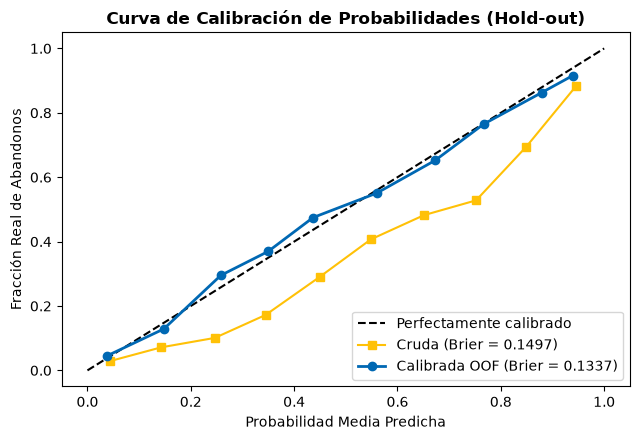

In [11]:
assert modelo_final_nombre == "RegresionLogistica", "ajustar_calibracion_isotonica (utils_r2) está implementada para RegLog; si gana XGBoost hay que generalizarla."
cols_final = cols_60
pipe_final = clone(modelos[modelo_final_nombre]).fit(X_tr[cols_final], y_tr)

# Probabilidades crudas en hold-out
probs_cruda = pipe_final.predict_proba(X_te[cols_final])[:, 1]
brier_crudo = calcular_metricas_clasificacion(y_te, probs_cruda)["brier"]

# Calibrador isotónico OOF sobre train
calibrador = ajustar_calibracion_isotonica(pipe_final, X_tr[cols_final], y_tr, n_splits=5, semilla=SEMILLA)
probs_calib = calibrador.predict(probs_cruda)
probs_final = probs_calib
brier_calib = calcular_metricas_clasificacion(y_te, probs_calib)["brier"]

prob_media_cruda = float(probs_cruda.mean())
prob_media_calib = float(probs_calib.mean())
tasa_real_te = float(y_te.mean())

print(f"Modelo final: {modelo_final_nombre} con {len(cols_final)} columnas ({len(genes_60)} variables estables del GA)")
print(f"\nAuditoría de Calibración en Hold-out ({len(y_te):,} empresas):")
print(f"- Probabilidad media cruda     : {prob_media_cruda:.4f} (sesgada por el balanceo de clases)")
print(f"- Probabilidad media calibrada : {prob_media_calib:.4f} (tasa real del {tasa_real_te*100:.2f}%)")
print(f"- Brier Score en Hold-out      : {brier_crudo:.4f} -> {brier_calib:.4f} (reducción del {(1 - brier_calib/brier_crudo)*100:.1f}%)")

# Costo de parsimonia: todas las variables vs variables estables (misma familia, hold-out, sin calibrar)
pipe_completo = clone(modelos[modelo_final_nombre]).fit(X_tr, y_tr)
pr_completo = float(calcular_metricas_clasificacion(y_te, pipe_completo.predict_proba(X_te)[:, 1])["pr_auc"])
pr_parsim = float(calcular_metricas_clasificacion(y_te, probs_cruda)["pr_auc"])
print(f"\nCosto de parsimonia (PR-AUC hold-out): {X.shape[1]} vars = {pr_completo:.4f} | {len(cols_final)} vars = {pr_parsim:.4f} | brecha {pr_completo - pr_parsim:.4f} (1 SE del benchmark = {se_best:.4f})")

# Curva de calibración
frac_cruda, mean_pred_cruda = calibration_curve(y_te, probs_cruda, n_bins=10)
frac_calib, mean_pred_calib = calibration_curve(y_te, probs_calib, n_bins=10)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot([0, 1], [0, 1], "k--", label="Perfectamente calibrado")
ax.plot(mean_pred_cruda, frac_cruda, "s-", color="#FFC107", label=f"Cruda (Brier = {brier_crudo:.4f})")
ax.plot(mean_pred_calib, frac_calib, "o-", color="#0068B3", linewidth=2, label=f"Calibrada OOF (Brier = {brier_calib:.4f})")
ax.set_xlabel("Probabilidad Media Predicha")
ax.set_ylabel("Fracción Real de Abandonos")
ax.set_title("Curva de Calibración de Probabilidades (Hold-out)", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


# Resultado final de la calibración isotónica (Regresión Logística, 7 variables finales)
#### La regresión logística final usa 7 variables (crecimiento de empleo, rotación, satisfacción, uso de servicios, antigüedad, número de trabajadores y digitalización).
#### Como se entrena con `class_weight='balanced'`, sus probabilidades crudas sobrestiman el abandono: en el hold-out promedian 0,4155 frente a una tasa real de 30,30 %.
#### La calibración isotónica, ajustada solo con predicciones Out-of-Fold sobre Train, las deja en 0,2984, prácticamente alineadas con la tasa real, y reduce el Brier Score
#### de 0,1497 a 0,1337 (−10,7 %). Al ser una transformación monótona no cambia el orden de las empresas (el ranking de riesgo y los deciles se mantienen), pero sí hace que cada
#### probabilidad pueda leerse como un riesgo real: una empresa con 0,60 calibrado tiene alrededor de 60 % de probabilidad de abandono, útil para dimensionar la cartera en riesgo
#### y priorizar campañas. El costo de la parsimonia frente al modelo de 16 variables es de 0,0127 puntos de PR-AUC en hold-out (0,7516 vs 0,7389), superior a 1 error estándar
#### (0,0054), y se asume a cambio de un modelo más simple y explicable.
#### (Cifras de la ejecución del 2026-10-04; si cambian las variables estables o la semilla, actualizar este párrafo con la salida de la celda.)


# FASE 5d — EXPLICABILIDAD DEL MODELO FINAL (ODDS RATIOS DE LA REGRESIÓN LOGÍSTICA)
#### - La regresión logística se interpreta directamente: cada coeficiente (beta) es el efecto de la variable sobre el log-odds de abandono.
#### - Odds Ratio por 1 desviación estándar (OR = exp(beta_std)): cuánto se multiplican los odds de abandono cuando la variable sube 1 DE, con el resto constante.
#### - OR > 1 aumenta el riesgo de abandono; OR < 1 lo reduce. Se muestra el cambio porcentual de los odds con intervalo bootstrap del 95 % (300 remuestreos del train).

Odds Ratios del Modelo Final (RegresionLogistica, 7 variables estables) — por +1 desviación estándar:
          variable  coeficiente  odds_ratio  or_inf  or_sup  cambio_odds_pct
          rotacion       0.8860      2.4250  2.2480  2.5890         142.4520
      satisfaccion      -0.8540      0.4260  0.3820  0.4640         -57.4380
crecimiento_empleo      -0.8090      0.4450  0.4160  0.4780         -55.4670
        antiguedad      -0.7320      0.4810  0.4430  0.5210         -51.9020
     uso_servicios      -0.6890      0.5020  0.4560  0.5530         -49.7750
    digitalizacion      -0.3460      0.7070  0.6640  0.7430         -29.2570
  num_trabajadores      -0.2470      0.7810  0.7250  0.8340         -21.9000


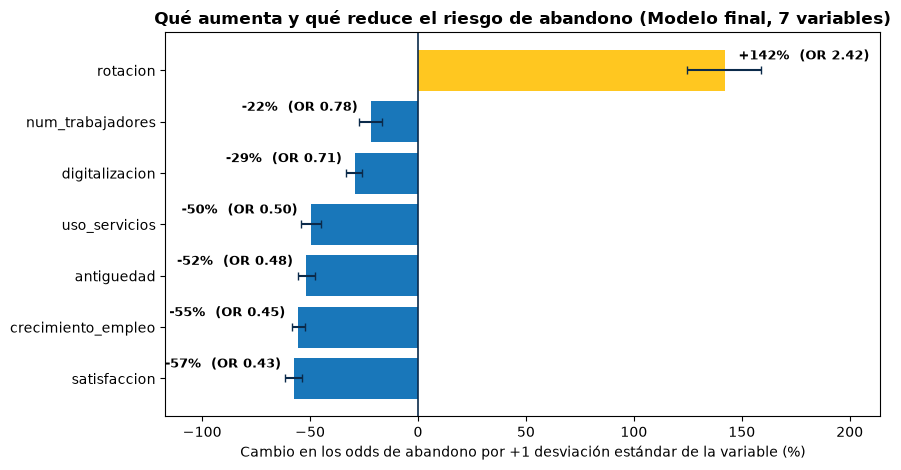

In [12]:
df_odds_final = calcular_explicabilidad_reglog(pipe_final, X_tr[cols_final], X_te[cols_final])

# Intervalo bootstrap 95 % del OR por 1 DE (refit del mismo pipeline sobre remuestreos del train)
rng = np.random.default_rng(SEMILLA)
n_tr = len(y_tr_a)
betas_boot = []
for _ in range(300):
    b = rng.integers(0, n_tr, n_tr)
    m_b = clone(pipe_final).fit(X_tr[cols_final].iloc[b], y_tr_a[b])
    betas_boot.append(m_b.named_steps["logisticregression"].coef_[0])
betas_boot = np.array(betas_boot)

# betas_boot sigue el orden de cols_final; se alinea por nombre de variable
ic = pd.DataFrame({"or_inf": np.exp(np.percentile(betas_boot, 2.5, axis=0)),
                   "or_sup": np.exp(np.percentile(betas_boot, 97.5, axis=0))}, index=cols_final)
df_odds_final["or_inf"] = df_odds_final["variable"].map(ic["or_inf"])
df_odds_final["or_sup"] = df_odds_final["variable"].map(ic["or_sup"])
df_odds_final["cambio_odds_pct"] = (df_odds_final["odds_ratio"] - 1) * 100

print(f"Odds Ratios del Modelo Final ({modelo_final_nombre}, {len(cols_final)} variables estables) — por +1 desviación estándar:")
print(df_odds_final.sort_values("impacto_absoluto", ascending=False)[["variable", "coeficiente", "odds_ratio", "or_inf", "or_sup", "cambio_odds_pct"]].round(3).to_string(index=False))

# Gráfico: cambio porcentual de los odds de abandono por +1 DE (barras de error = IC bootstrap 95 %)
d = df_odds_final.sort_values("cambio_odds_pct")
y_pos = np.arange(len(d))
colores = ["#FFC107" if v > 0 else "#0068B3" for v in d["cambio_odds_pct"]]
err = np.array([d["cambio_odds_pct"] - (d["or_inf"] - 1) * 100, (d["or_sup"] - 1) * 100 - d["cambio_odds_pct"]])
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(y_pos, d["cambio_odds_pct"], xerr=np.clip(err, 0, None), color=colores, alpha=0.9, capsize=3, ecolor="#0B2A4A")
for yi, (v, o) in enumerate(zip(d["cambio_odds_pct"], d["odds_ratio"])):
    ax.text(v + (6 if v > 0 else -6), yi + 0.28, f"{v:+.0f}%  (OR {o:.2f})", ha="left" if v > 0 else "right", va="center", fontsize=9.5, fontweight="bold")
ax.axvline(0, color="#0B2A4A", linewidth=1.2)
ax.set_yticks(y_pos)
ax.set_yticklabels(d["variable"])
ax.set_xlabel("Cambio en los odds de abandono por +1 desviación estándar de la variable (%)")
ax.set_title(f"Qué aumenta y qué reduce el riesgo de abandono (Modelo final, {len(cols_final)} variables)", fontweight="bold")
ax.margins(x=0.25)
plt.tight_layout()
plt.show()


# FASE 6 — DESPLIEGUE Y ESTRATEGIA COMERCIAL
#### - Construcción de los 10 deciles comerciales exactos (200 empresas por decil) ordenados por probabilidad calibrada
####   con desempate estricto por la probabilidad cruda (ranking exacto).
#### - Curva de Lift y Ganancias Acumuladas.
#### - Cuantificación de impacto: Empresas contactadas vs abandonos capturados en el Top 20% (400 cuentas).
#### - Supuestos económicos transparentes del plan de retención.

Tabla de Deciles Comerciales Calibrados (Hold-out 2,000 Empresas - Ranking Exacto de 200 Cuentas):
 decil  empresas  abandonos  tasa_abandono  prob_promedio  pct_capturado   lift
     1       200        176         0.8800         0.8672        29.0429 2.9043
     2       200        129         0.6450         0.6706        50.3300 2.1287
     3       200        100         0.5000         0.4914        66.8317 1.6502
     4       200         76         0.3800         0.3509        79.3729 1.2541
     5       200         56         0.2800         0.2405        88.6139 0.9241
     6       200         26         0.1300         0.1634        92.9043 0.4290
     7       200         17         0.0850         0.1036        95.7096 0.2805
     8       200         14         0.0700         0.0585        98.0198 0.2310
     9       200         10         0.0500         0.0316        99.6700 0.1650
    10       200          2         0.0100         0.0066       100.0000 0.0330

RESULTADOS Y EFECTIV

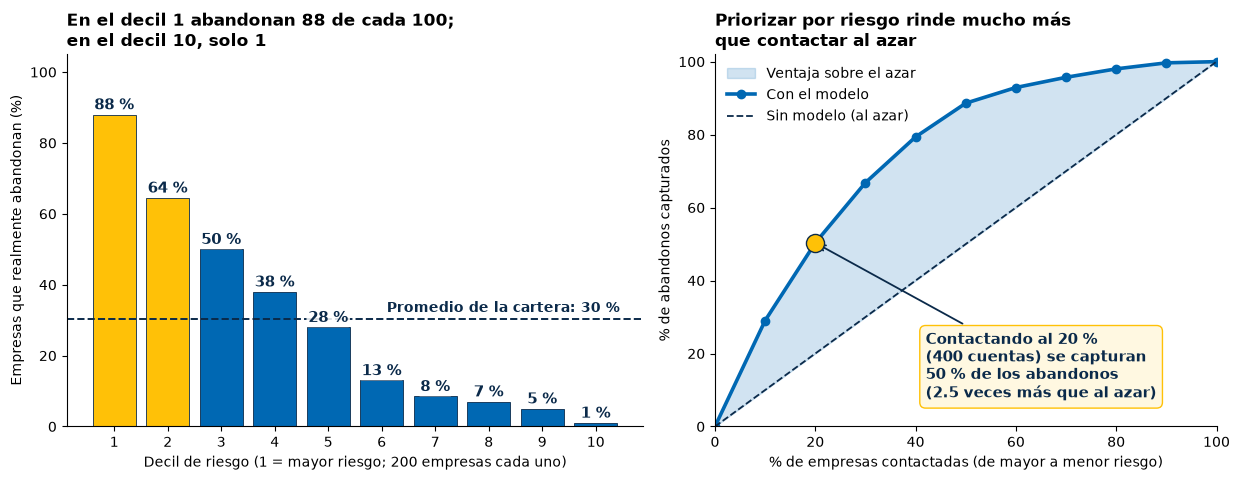


SUPUESTOS ECONÓMICOS DEL PLAN DE RETENCIÓN:
- El costo operativo de contactar y negociar con una empresa NO está registrado en los datos (es un [SUPUESTO] declarado).
- La focalización en el Top 20% (400 cuentas) minimiza el gasto comercial previniendo intervenciones innecesarias en el 80% restante.
- Para la presentación ejecutiva, el impacto se reporta de forma honesta en cuentas contactadas vs capturadas.


In [15]:
probs_cruda_final = pipe_final.predict_proba(X_te[cols_final])[:, 1]
deciles = analizar_deciles_calibrados(y_te, probs_final, probs_crudas=probs_cruda_final)
print("Tabla de Deciles Comerciales Calibrados (Hold-out 2,000 Empresas - Ranking Exacto de 200 Cuentas):")
print(deciles[["decil", "empresas", "abandonos", "tasa_abandono", "prob_promedio", "pct_capturado", "lift"]].to_string(index=False))

lift_d1 = float(deciles.loc[deciles["decil"] == 1, "lift"].values[0])
tasa_d1 = float(deciles.loc[deciles["decil"] == 1, "tasa_abandono"].values[0])
pct_top20 = float(deciles.loc[deciles["decil"] <= 2, "pct_capturado"].max())
empresas_top20 = int(deciles.loc[deciles["decil"] <= 2, "empresas"].sum())
abandonos_top20 = int(deciles.loc[deciles["decil"] <= 2, "abandonos"].sum())
total_abandonos_te = int(y_te.sum())

print(f"\nRESULTADOS Y EFECTIVIDAD COMERCIAL:")
print(f"1. Lift en Decil 1: {lift_d1:.3f}x (Tasa de abandono: {tasa_d1*100:.2f}% vs base del {tasa_real_te*100:.2f}%).")
print(f"2. Recall en Top 20% (Deciles 1 y 2): Se contactan {empresas_top20} cuentas y se capturan {abandonos_top20} de los {total_abandonos_te} retiros reales ({pct_top20:.2f}%).")
print(f"3. Eficiencia de Focalización: Se rescata más de la mitad de las bajas ({pct_top20:.2f}%) contactando a solo 1 de cada 5 empresas.")

# Gráfico comercial: dónde está el riesgo y cuánto se captura al priorizar (2 paneles)
AZUL, AMARILLO, NAVY, GRIS = "#0068B3", "#FFC107", "#0B2A4A", "#B0BEC5"
fig, (axa, axb) = plt.subplots(1, 2, figsize=(12.5, 4.9), gridspec_kw={"width_ratios": [1.15, 1]})

# Panel A: tasa real de abandono por decil de riesgo (los 2 primeros deciles = top 20 %)
tasas = deciles["tasa_abandono"].values * 100
axa.bar(deciles["decil"], tasas, color=[AMARILLO if d <= 2 else AZUL for d in deciles["decil"]], edgecolor=NAVY, linewidth=0.6)
axa.axhline(tasa_real_te * 100, color=NAVY, linestyle="--", linewidth=1.4)
axa.text(10.45, tasa_real_te * 100 + 2, f"Promedio de la cartera: {tasa_real_te*100:.0f} %", ha="right", fontsize=10, color=NAVY, fontweight="bold")
for d, t in zip(deciles["decil"], tasas):
    axa.text(d, t + 1.5, f"{t:.0f} %", ha="center", fontsize=10.5, fontweight="bold", color=NAVY,
             bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.85))
axa.set_xticks(range(1, 11))
axa.set_xlabel("Decil de riesgo (1 = mayor riesgo; 200 empresas cada uno)")
axa.set_ylabel("Empresas que realmente abandonan (%)")
axa.set_ylim(0, 105)
axa.set_title(f"En el decil 1 abandonan {tasas[0]:.0f} de cada 100;\nen el decil 10, solo {tasas[-1]:.0f}", fontweight="bold", fontsize=12, loc="left")
axa.spines[["top", "right"]].set_visible(False)

# Panel B: ganancias acumuladas contra contactar al azar
x_c = np.array([0] + list(range(1, 11))) * 10
y_c = np.array([0] + list(deciles["pct_capturado"]))
axb.fill_between(x_c, x_c, y_c, color=AZUL, alpha=0.18, label="Ventaja sobre el azar")
axb.plot(x_c, y_c, "o-", color=AZUL, linewidth=2.6, label="Con el modelo")
axb.plot([0, 100], [0, 100], "--", color=NAVY, linewidth=1.3, label="Sin modelo (al azar)")
axb.scatter([20], [pct_top20], s=170, color=AMARILLO, edgecolor=NAVY, zorder=5)
axb.annotate(f"Contactando al 20 %\n(400 cuentas) se capturan\n{pct_top20:.0f} % de los abandonos\n({pct_top20/20:.1f} veces más que al azar)",
             xy=(20, pct_top20), xytext=(42, 8), fontsize=10.5, fontweight="bold", color=NAVY,
             arrowprops=dict(arrowstyle="->", color=NAVY, linewidth=1.3), bbox=dict(boxstyle="round,pad=0.4", fc="#FFF8E1", ec=AMARILLO))
axb.set_xlabel("% de empresas contactadas (de mayor a menor riesgo)")
axb.set_ylabel("% de abandonos capturados")
axb.set_xlim(0, 100); axb.set_ylim(0, 102)
axb.set_title("Priorizar por riesgo rinde mucho más\nque contactar al azar", fontweight="bold", fontsize=12, loc="left")
axb.legend(loc="upper left", frameon=False)
axb.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("\nSUPUESTOS ECONÓMICOS DEL PLAN DE RETENCIÓN:")
print("- El costo operativo de contactar y negociar con una empresa NO está registrado en los datos (es un [SUPUESTO] declarado).")
print("- La focalización en el Top 20% (400 cuentas) minimiza el gasto comercial previniendo intervenciones innecesarias en el 80% restante.")
print("- Para la presentación ejecutiva, el impacto se reporta de forma honesta en cuentas contactadas vs capturadas.")



# FASE 6B — MATRIZ DE CONFUSIÓN EN HOLD-OUT (TEST) Y DOS FORMAS DE USAR EL MODELO
#### - Umbral estadístico: probabilidad cruda >= 0,5 (el modelo está balanceado, por eso 0,5 ya equilibra aciertos en ambas clases). Es el punto con el que se midió F1 y exactitud.
#### - Política comercial: contactar al 20 % de empresas con mayor riesgo (400 cuentas); es la forma real en que el área de negocio usaría el ranking.
#### - Ambas matrices se calculan sobre las 2,000 empresas del hold-out, que el modelo nunca vio.

A. Umbral 0,5
   Aciertos de abandono (VP)=466 | Falsas alarmas (FP)=288 | Abandonos no detectados (FN)=140 | Continúan bien clasificadas (VN)=1106
   Exactitud=0.786 | Precisión=0.618 | Recall=0.769 | F1=0.685

B. Contactar al 20 % de mayor riesgo (400 cuentas)
   Aciertos de abandono (VP)=305 | Falsas alarmas (FP)=95 | Abandonos no detectados (FN)=301 | Continúan bien clasificadas (VN)=1299
   Exactitud=0.802 | Precisión=0.762 | Recall=0.503 | F1=0.606



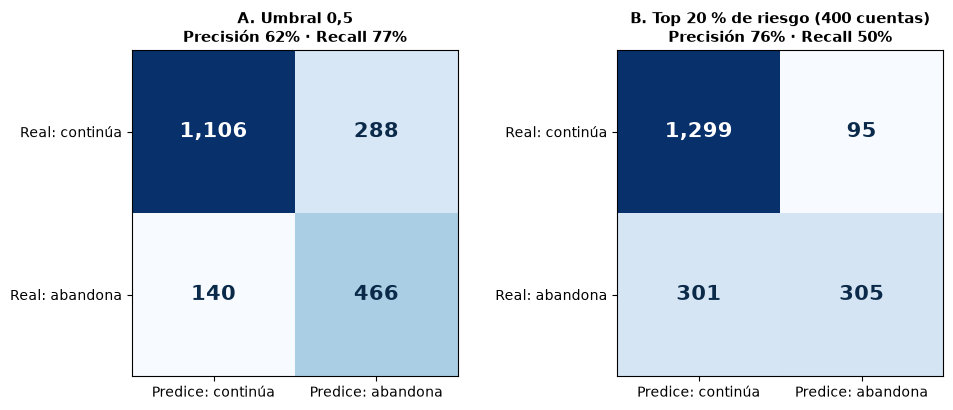

In [14]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

def resumen_confusion(y_real, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_real, y_pred).ravel()
    return dict(tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp),
                exactitud=(tn + tp) / len(y_real), precision=precision_score(y_real, y_pred), recall=recall_score(y_real, y_pred),
                f1=f1_score(y_real, y_pred))

# A. Umbral estadístico 0,5 sobre la probabilidad cruda del modelo final
pred_umbral = (probs_cruda_final >= 0.5).astype(int)
cm_umbral = resumen_confusion(y_te, pred_umbral)

# B. Política comercial: top 20 % de mayor riesgo (mismo ranking exacto de los deciles)
orden = np.lexsort((-probs_cruda_final, -probs_final))
pred_top20 = np.zeros(len(y_te), dtype=int)
pred_top20[orden[:400]] = 1
cm_top20 = resumen_confusion(y_te, pred_top20)

for nombre, cm in [("A. Umbral 0,5", cm_umbral), ("B. Contactar al 20 % de mayor riesgo (400 cuentas)", cm_top20)]:
    print(f"{nombre}")
    print(f"   Aciertos de abandono (VP)={cm['tp']} | Falsas alarmas (FP)={cm['fp']} | Abandonos no detectados (FN)={cm['fn']} | Continúan bien clasificadas (VN)={cm['tn']}")
    print(f"   Exactitud={cm['exactitud']:.3f} | Precisión={cm['precision']:.3f} | Recall={cm['recall']:.3f} | F1={cm['f1']:.3f}\n")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, (titulo, cm) in zip(axes, [("A. Umbral 0,5", cm_umbral), ("B. Top 20 % de riesgo (400 cuentas)", cm_top20)]):
    mat = np.array([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]])
    ax.imshow(mat, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{mat[i, j]:,}", ha="center", va="center", fontsize=15, fontweight="bold",
                    color="white" if mat[i, j] > mat.max() * 0.55 else "#0B2A4A")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Predice: continúa", "Predice: abandona"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Real: continúa", "Real: abandona"])
    ax.set_title(f"{titulo}\nPrecisión {cm['precision']:.0%} · Recall {cm['recall']:.0%}", fontweight="bold", fontsize=11)
plt.tight_layout()
plt.show()

## Cómo leer los resultados del modelo (hold-out de 2.000 empresas, 606 abandonos reales)
#
#### **Qué tan bien acierta.** Con el umbral de 0,5 el modelo detecta 466 de los 606 abandonos (recall 76,9 %) y acierta 1.106 de las 1.394 empresas que continúan; la exactitud es de 78,6 % y el F1 de 0,685.
#### El costo de ese nivel de detección son 288 falsas alarmas (empresas que el modelo marca en riesgo y se quedan), de modo que de cada 100 empresas señaladas, unas 62 realmente se van (precisión 61,8 %).
#### Los 140 abandonos restantes pasan sin ser detectados con ese umbral.
#
#### **Cómo se usa en la práctica.** El área comercial no puede llamar a todas las empresas marcadas, así que se prioriza por riesgo. Al contactar solo al 20 % de la cartera (400 cuentas) se alcanzan 305 de los 606 abandonos (50,3 %)
#### y 3 de cada 4 empresas contactadas (76 %) sí estaban por irse; en el decil de mayor riesgo, 88 de cada 100 empresas abandonan, frente a 30 de cada 100 en toda la cartera (2,9 veces más).
#### En el decil de menor riesgo abandona solo 1 de cada 100. Es decir, el modelo ordena bien: las probabilidades calibradas permiten saber a quién llamar primero.
#
#### **Qué empuja el abandono (odds ratios por +1 desviación estándar, con el resto igual).** La rotación de personal es el factor que más aumenta el riesgo: sus odds de abandono se multiplican por 2,4 (+142 %).
#### Todos los demás factores protegen: mayor satisfacción (−57 %), crecimiento del empleo (−55 %), antigüedad (−52 %), uso de servicios (−50 %), digitalización (−29 %) y número de trabajadores (−22 %).
#### Los intervalos del 95 % no se cruzan con 1 en ninguna variable, así que la dirección de cada efecto es estable.
#
#### **Qué hacer con esto (acciones para el área de negocio).**
#### 1. *Llamar primero a los deciles 1 y 2 (400 cuentas).* Concentran 305 de los 606 abandonos del hold-out; un gestor dedicado por este grupo rinde mucho más que una campaña masiva.
#### 2. *Para los deciles 3 y 4 (tasa de abandono 50 % y 38 %), acciones de bajo costo:* comunicación automatizada, encuesta de satisfacción y ofertas de servicios; reservar la atención personalizada al top 20 %.
#### 3. *Deciles 5 a 10 (abandono de 28 % o menos): monitoreo,* sin inversión adicional; el decil 10 casi no abandona (1 %).
#### 4. *Atacar los factores que se pueden gestionar con la empresa:* satisfacción y uso de servicios (portafolio, beneficios), y digitalización (acompañamiento en adopción); están asociados a menos abandono y son los que Colsubsidio puede mover.
#### 5. *Tratar la rotación alta como señal de alerta temprana:* una empresa con rotación muy por encima del promedio merece contacto aunque hoy esté al día en sus aportes.
#### 6. *Recalibrar y reentrenar* cada trimestre con los abandonos nuevos y seguir el desempeño por decil; la calibración permite además dimensionar cartera en riesgo (probabilidad × aporte).
#
#### **Límites que conviene decir en voz alta.** El costo de contactar a una empresa y el valor de retenerla no están en los datos, por lo que el retorno económico del plan es un supuesto que el área debe aportar; las cifras de este párrafo son del hold-out de esta ejecución
#### (semilla 42) y los efectos de los factores describen asociaciones del modelo, útiles para priorizar acciones que luego conviene validar con un piloto.
